# California housing price prediction
### Goal:
Predict the value of houses in california based on a variety of factors

In [1]:
# imports
import pandas as pd
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

## Data loading and preprocessing
### Load and display data
Specifying target column for easier use down the line

Can change said column later if wanted

In [2]:
# load data
target_value = "median_house_value"
data = pd.read_csv("housing.csv")
y_vals = data[target_value]
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Encode ocean_proximity
Data should be a numerical value

In [3]:
print("Ocean Proximity values: ", data["ocean_proximity"].unique())
data["ocean_proximity"] = data["ocean_proximity"].astype("category") # convert to category type
data["ocean_proximity"] = data["ocean_proximity"].cat.codes # convert to numerical values
data.head()

Ocean Proximity values:  ['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


### Missing values
The data does contain missing values

Using mean imputation to fill values, could use something like knn or drop rows/columns instead if wanted

Dropping target column here as well

In [4]:
data = data.drop(target_value, axis=1)
has_nan = data.isnull().values.any() # any bad vals?
if has_nan:
    print("Data contains NaN values")
    data = data.fillna(data.mean())
else:
    print("Data does not contain NaN values")

Data contains NaN values


## Feature selection

##### Removing highly correlated variables
With a correlation coefficient of 0.85

Correlation matrix for good visualization

Changing to 0.9 gives worse accuracy metrics

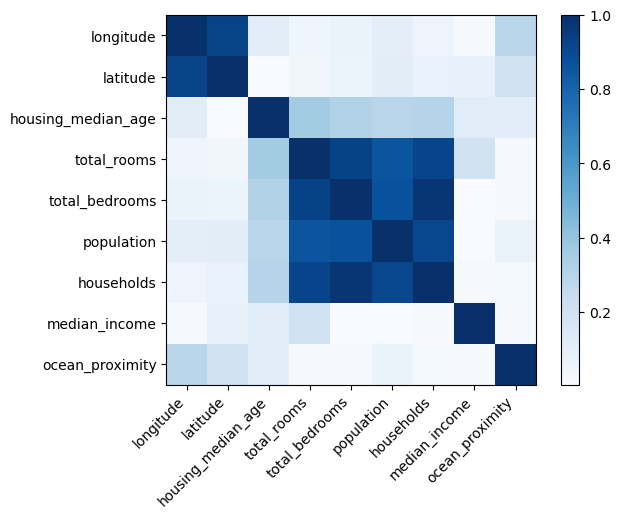

Dropping:  ['latitude', 'total_bedrooms', 'population', 'households']


In [5]:
mat = data.corr().abs() # get correlation matrix, abs is fine because mag is what we care about
upper = mat.where(np.triu(np.ones(mat.shape), k=1).astype(np.bool)) # get upper triangle of matrix
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)] # get columns to drop

plt.imshow(mat, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(mat)), data.columns, rotation=45, ha='right')
plt.yticks(range(len(mat)), data.columns)
plt.show()

data = data.drop(to_drop, axis=1)
print("Dropping: ", to_drop)

### K best
This is mostly useless, k is not specified

Can specify some k value, but reduces accuracy metrics (most metrics in most cases)

In [6]:
test = SelectKBest(score_func=f_regression) # can set k= to number of features you want
selected = test.fit_transform(data, y_vals)
selected_features = data.columns[test.get_support()]
data = data[selected_features]
print("Selected features: ", selected_features)

Selected features:  Index(['longitude', 'housing_median_age', 'total_rooms', 'median_income',
       'ocean_proximity'],
      dtype='object')


## Data splitting and model building

### Scaling all values and split for Linear Model
The code is a little weird but it works

In [7]:
scaler = StandardScaler()
data_all = data.copy()
data_all[target_value] = y_vals
data_scaled = scaler.fit_transform(data_all)
data_scaled = pd.DataFrame(data_scaled, columns=data_all.columns)
y_vals = data_scaled[target_value]
data_scaled = data_scaled.drop(target_value, axis=1)
X_train, X_test, y_train, y_test = train_test_split(data_scaled, y_vals, test_size=0.2, random_state=42)

### Building, training, and getting predicted vals for Linear Model

In [8]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_y_pred = lin_model.predict(X_test)

### Polynomial transformation of variables

In [9]:
# transform model to polynomial regreession model
poly_degree = 3
poly = PolynomialFeatures(degree=poly_degree)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(poly.fit_transform(data_scaled), y_vals, test_size=0.2, random_state=42)

### Model stuff for Polynomial Model

In [10]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

poly_y_pred = poly_model.predict(X_test_poly)

## Evaluation metrics

### R<sup>2</sup>

In [11]:
lin_r2_test = r2_score(y_test, lin_y_pred) 
poly_r2_test = r2_score(y_test_poly, poly_y_pred) 

print(f'linear model\'s R-squared (R²) for Testing Data: {lin_r2_test}')
print(f'polynomial model\'s R-squared (R²) for Testing Data: {poly_r2_test}')

linear model's R-squared (R²) for Testing Data: 0.506402701154509
polynomial model's R-squared (R²) for Testing Data: 0.6298162487554776


### MSE

In [12]:
lin_mse_test = mean_squared_error(y_test, lin_y_pred)
poly_mse_test = mean_squared_error(y_test_poly, poly_y_pred)  

print(f'linear model\'s Mean Squared Error (MSE) for Testing Data: {lin_mse_test}')
print(f'polynomial model\'s Mean Squared Error (MSE) for Testing Data: {poly_mse_test}')

linear model's Mean Squared Error (MSE) for Testing Data: 0.48576034416638186
polynomial model's Mean Squared Error (MSE) for Testing Data: 0.3643062610551888


### MAE

In [13]:
lin_mae_test = mean_absolute_error(y_test, lin_y_pred)
poly_mae_test = mean_absolute_error(y_test_poly, poly_y_pred)

print(f'linear model\'s Mean Absolute Error (MAE) for Testing Data: {lin_mae_test}')
print(f'polynomial model\'s Mean Absolute Error (MAE) for Testing Data: {poly_mae_test}')

linear model's Mean Absolute Error (MAE) for Testing Data: 0.5173553007950201
polynomial model's Mean Absolute Error (MAE) for Testing Data: 0.4266381955872733


### Plotting actual vs predicted
x = actual, y = predicted

line indicates actual = predicted

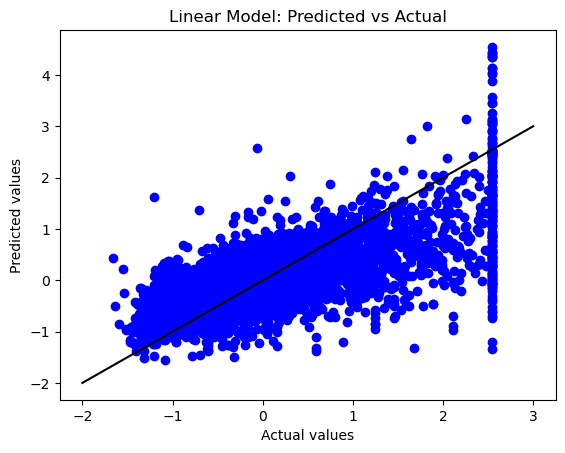

In [14]:
# linear model
plt.figure(1)
plt.scatter(y_test, lin_y_pred, color='blue', label='linear model')
plt.plot(np.linspace(-2, 3, 100), np.linspace(-2, 3, 100), color='black')
plt.title('Linear Model: Predicted vs Actual')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()

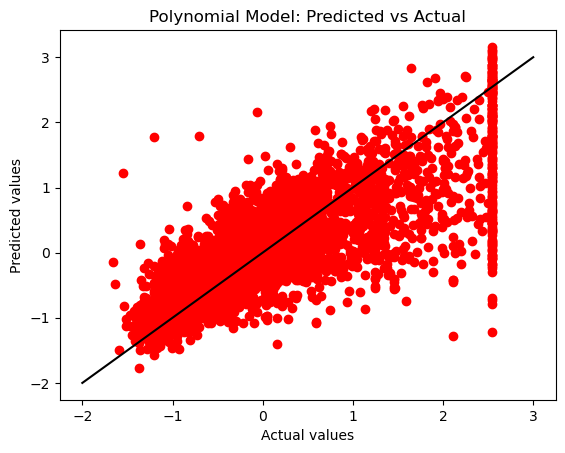

In [15]:
# polynomial model
plt.figure(2)
plt.scatter(y_test_poly, poly_y_pred, color='red', label='polynomial model')
plt.plot(np.linspace(-2, 3, 100), np.linspace(-2, 3, 100), color='black')
plt.title('Polynomial Model: Predicted vs Actual')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()